In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import pandas as pd

2025-10-30 14:50:16.132173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-30 14:50:16.867090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761816016.913392  129902 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761816016.925578  129902 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761816017.240560  129902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:

path = "/scratch/shambhavij.sps.iitmandi/LightCurve2Map/FinalData/"

# --- Load the additional circular datasets ---
test_lc0 = np.load(path + "LC10_set1/ntest_type0LC.npy")
test_shape0 = np.load(path + "OM10/test_type0.npy")

circle_types = ["type0"]
mega_types   = ["typeIa", "typeIb", "typeIIa", "typeIIb", "typeIII", "typeIV", "typeV"]

X_test_list, y_test_list = [], []

# --- Circles → label 0 ---
for t in circle_types:
    X_test_list.append(np.load(f"{path}LC10_set1/test_{t}LC.npy"))
    y_test_list.append(np.zeros(len(X_test_list[-1])))

# Include new circular datasets
X_test_list.append(test_lc0)
y_test_list.append(np.zeros(len(test_lc0)))

# --- Megastructure candidates → label 1 ---
for t in mega_types:
    X_test_list.append(np.load(f"{path}LC10_set1/test_{t}LC.npy"))
    y_test_list.append(np.ones(len(X_test_list[-1])))

# Concatenate all test data
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)


In [3]:

print("Test set:", X_test.shape, y_test.shape)
print("Label distribution (test):", np.unique(y_test, return_counts=True))


Test set: (10140, 120) (10140,)
Label distribution (test): (array([0., 1.]), array([2500, 7640]))


In [4]:
# --- Load the trained model ---
model = keras.models.load_model("Models/0Binary_MegaClassifier_Final.keras", compile=False)

# Compile (for metrics evaluation)
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy", keras.metrics.AUC(name="AUC")])

# --- Evaluate on test set ---
results = model.evaluate(X_test, y_test, batch_size=256, verbose=2)
print("\n✅ Test Results:")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")


2025-10-30 14:51:37.994351: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


40/40 - 1s - 35ms/step - AUC: 0.9499 - accuracy: 0.8518 - loss: 0.3210

✅ Test Results:
loss: 0.3210
compile_metrics: 0.8518


In [5]:

# --- Predict and analyze ---
y_pred = model.predict(X_test, batch_size=256).ravel()

# Optional threshold-based classification
threshold = 0.5
y_pred_label = (y_pred >= threshold).astype(int)

# --- Compute confusion matrix & classification report ---

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_label))
print("\nClassification Report:\n", classification_report(y_test, y_pred_label, digits=4))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Confusion Matrix:
 [[2460   40]
 [1463 6177]]



Classification Report:
               precision    recall  f1-score   support

         0.0     0.6271    0.9840    0.7660      2500
         1.0     0.9936    0.8085    0.8915      7640

    accuracy                         0.8518     10140
   macro avg     0.8103    0.8963    0.8288     10140
weighted avg     0.9032    0.8518    0.8606     10140


ROC-AUC: 0.9499373560209423


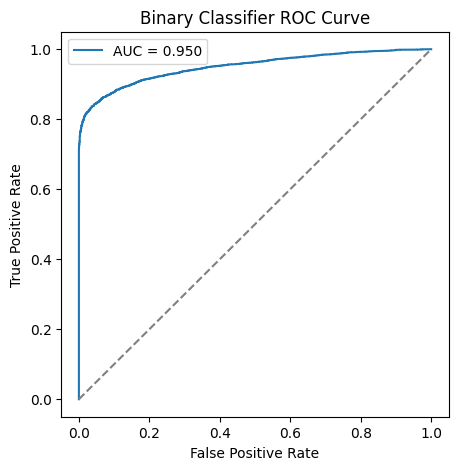

In [6]:
# --- Plot ROC curve (optional) ---
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred):.3f}")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary Classifier ROC Curve")
plt.legend()
plt.show()

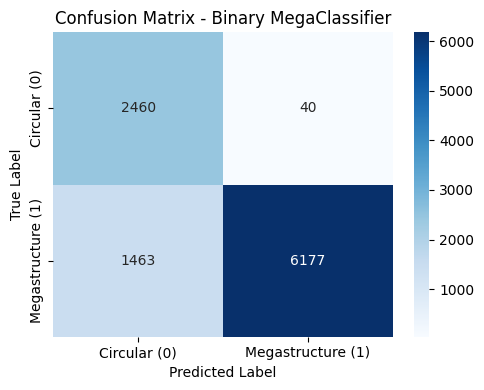

In [7]:
# --- Plot Confusion Matrix ---
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_label)
labels = ["Circular (0)", "Megastructure (1)"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Binary MegaClassifier")
plt.tight_layout()
plt.show()


In [8]:
# --- After model prediction ---
y_pred = model.predict(X_test, batch_size=256).ravel()
y_pred_label = (y_pred >= 0.5).astype(int)

# --- Map back dataset type for each test example ---
circle_types = ["type0"]
mega_types   = ["typeIa", "typeIb", "typeIIa", "typeIIb", "typeIII", "typeIV", "typeV"] 

# Build a parallel list of type names for each block
type_labels = []

# Circles
for t in circle_types:
    type_labels.extend([t] * len(np.load(f"{path}LC10_set1/test_{t}LC.npy")))

# Add new circular set (ntest_type0)
type_labels.extend(["type0"] * len(test_lc0))

# Megastructures
for t in mega_types:
    type_labels.extend([t] * len(np.load(f"{path}LC10_set1/test_{t}LC.npy")))

type_labels = np.array(type_labels)
assert len(type_labels) == len(y_test), "Length mismatch between labels and predictions!"

# --- Compute correct/incorrect per type ---
summary = []
for t in np.unique(type_labels):
    idx = (type_labels == t)
    total = np.sum(idx)
    correct = np.sum(y_pred_label[idx] == y_test[idx])
    incorrect = total - correct
    accuracy = correct / total * 100
    summary.append([t, total, correct, incorrect, f"{accuracy:.2f}%"])

# --- Make DataFrame ---
df_summary = pd.DataFrame(summary, columns=["Type", "Total", "Correct", "Incorrect", "Accuracy"])
print(df_summary)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
      Type  Total  Correct  Incorrect Accuracy
0    type0   2500     2460         40   98.40%
1  typeIII    480      280        200   58.33%
2  typeIIa   2000     1872        128   93.60%
3  typeIIb    840      647        193   77.02%
4   typeIV    960      769        191   80.10%
5   typeIa    960      561        399   58.44%
6   typeIb    400      335         65   83.75%
7    typeV   2000     1713        287   85.65%
